Here I will try to calculate the Wigner function from numpy's FFT. I will not yet use NIFTy FFT because I do not know what convention is used in the C++ implementation.

First of all: Does $\texttt{numpy}$ do what I think it does?

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [63]:
# Discretizing a Riemann sum * Δk to give rise to a pure sine:

N = 1000
L  = 0.5
dt = L/N
dk = 1.0 / L
k_nyquist = 1/(2*dt)

t = np.linspace(0, L, N, endpoint=False)

k = np.linspace(-k_nyquist, k_nyquist, N, endpoint=False)
print(k)
k_star_idx = np.argmin(np.abs(k-5))

k_star = k[k_star_idx]
omega = 2*np.pi*k_star
print("choosing k star of ", k_star)
print("Frequency of sine wave omega = ", omega)

A = np.zeros(N, dtype=complex)
A[k_star_idx] = 1
A[-k_star_idx] = -1

A /= 2j

integral_result_physical_k = []
for x in t:
    to_sum = []
    for l in range(len(A)):
        summand = np.exp(2*np.pi*1j*x*k[l]) * A[l]
        to_sum.append(summand)

    integral = sum(to_sum)
    integral_result_physical_k.append(integral)




[-1000.  -998.  -996.  -994.  -992.  -990.  -988.  -986.  -984.  -982.
  -980.  -978.  -976.  -974.  -972.  -970.  -968.  -966.  -964.  -962.
  -960.  -958.  -956.  -954.  -952.  -950.  -948.  -946.  -944.  -942.
  -940.  -938.  -936.  -934.  -932.  -930.  -928.  -926.  -924.  -922.
  -920.  -918.  -916.  -914.  -912.  -910.  -908.  -906.  -904.  -902.
  -900.  -898.  -896.  -894.  -892.  -890.  -888.  -886.  -884.  -882.
  -880.  -878.  -876.  -874.  -872.  -870.  -868.  -866.  -864.  -862.
  -860.  -858.  -856.  -854.  -852.  -850.  -848.  -846.  -844.  -842.
  -840.  -838.  -836.  -834.  -832.  -830.  -828.  -826.  -824.  -822.
  -820.  -818.  -816.  -814.  -812.  -810.  -808.  -806.  -804.  -802.
  -800.  -798.  -796.  -794.  -792.  -790.  -788.  -786.  -784.  -782.
  -780.  -778.  -776.  -774.  -772.  -770.  -768.  -766.  -764.  -762.
  -760.  -758.  -756.  -754.  -752.  -750.  -748.  -746.  -744.  -742.
  -740.  -738.  -736.  -734.  -732.  -730.  -728.  -726.  -724.  -722.
  -720

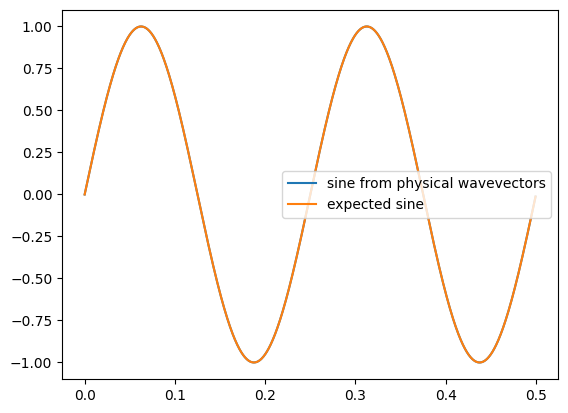

In [59]:
plt.plot(t, integral_result_physical_k, label="sine from physical wavevectors")
plt.plot(t, np.sin(omega*t), label="expected sine")
plt.legend()
plt.show()

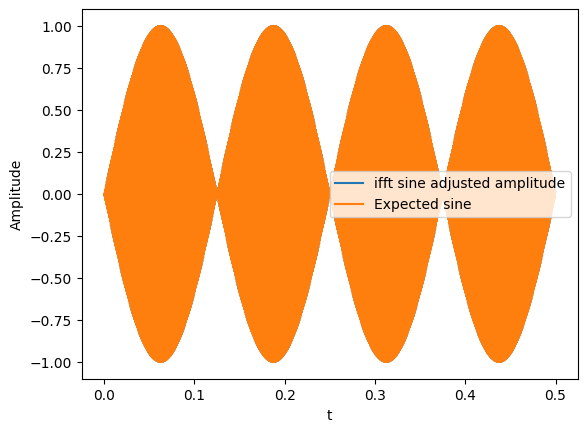

Mean imaginary part (ifft): 3.9799280640465904e-20


In [62]:
# using FFT:

# --- inverse FFT ---
x_ifft = np.fft.ifft(A)

expected_period_due_to_np = L/k_star_idx  # numpy discretizes the exponent as 1/N *m*l whereas above, I subtracted Δx*m*k_Nyquist to account for the negative frequencies
f_tmp = 1/expected_period_due_to_np

# --- plotting ---

plt.plot(t, x_ifft.real*N, label="ifft sine adjusted amplitude")
plt.plot(t, np.sin(2*np.pi*f_tmp*t), label="Expected sine")

plt.xlabel("t")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

# check imaginary part
print("Mean imaginary part (ifft):", np.mean(np.abs(x_ifft.imag)))



Therefore, if the only difference lies in that numpy uses this standard DFT ordering, we should get the same result if we transform our $A(k)$ array that is ordered as negative frequencies first, 0, positive frequencies into an array $A(k)^{\prime}$ that uses the DFT standard order.

k reordered:  [    0.     2.     4.     6.     8.    10.    12.    14.    16.    18.
    20.    22.    24.    26.    28.    30.    32.    34.    36.    38.
    40.    42.    44.    46.    48.    50.    52.    54.    56.    58.
    60.    62.    64.    66.    68.    70.    72.    74.    76.    78.
    80.    82.    84.    86.    88.    90.    92.    94.    96.    98.
   100.   102.   104.   106.   108.   110.   112.   114.   116.   118.
   120.   122.   124.   126.   128.   130.   132.   134.   136.   138.
   140.   142.   144.   146.   148.   150.   152.   154.   156.   158.
   160.   162.   164.   166.   168.   170.   172.   174.   176.   178.
   180.   182.   184.   186.   188.   190.   192.   194.   196.   198.
   200.   202.   204.   206.   208.   210.   212.   214.   216.   218.
   220.   222.   224.   226.   228.   230.   232.   234.   236.   238.
   240.   242.   244.   246.   248.   250.   252.   254.   256.   258.
   260.   262.   264.   266.   268.   270.   272.   274.   276.

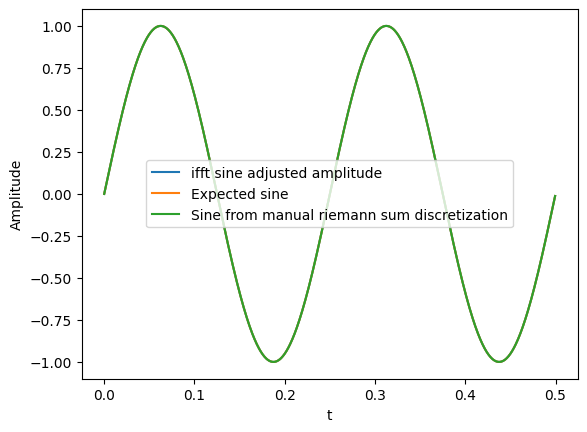

Mean imaginary part (ifft): 3.9799280640465904e-20


In [73]:
# using FFT:

A_reordered = np.fft.ifftshift(A)  # now matches FFT ordering
k_reordered = np.fft.ifftshift(k)

print("k reordered: ", k_reordered)

# --- inverse FFT ---
x_ifft = np.fft.ifft(A_reordered)

print(np.where(0!=A_reordered)[0][1])
k_star_idx_reordered = np.where(0!=A_reordered)[0][0]  # [0][0] corresponds to the positive frequency, [0][1] to the negative

expected_period_due_to_np = L/k_star_idx_reordered  # numpy discretizes the exponent as 1/N *m*l whereas above, I subtracted Δx*m*k_Nyquist to account for the negative frequencies
f_tmp = 1/expected_period_due_to_np

# --- plotting ---

plt.plot(t, x_ifft.real*N, label="ifft sine adjusted amplitude")
plt.plot(t, np.sin(2*np.pi*f_tmp*t), label="Expected sine")
plt.plot(t, np.sin(omega*t), label="Sine from manual riemann sum discretization")

plt.xlabel("t")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

# check imaginary part
print("Mean imaginary part (ifft):", np.mean(np.abs(x_ifft.imag)))



I therefore conclude:

Discretizing the Riemann-Sum directly AND scaling with 1/Delta k (or: just leave the * Delta k factor out when constructing the sums) with an inherent ordering of
$f(k)$ (the function you want to transform) according to $k$'s that are ordered like:

$$k=[-1000, -998, ..., 0, ..., 998]$$

is _equivalent_ to numpy's iFFT function if and only if the function to be transformed is sorted according to the standard DFT order via:

$$f(k)^{\prime}=\texttt{np.fft.ifftshift}(f(k))$$

$$f(x) := N\cdot \texttt{np.fft.ifft}(f(k)^{\prime}).$$
